In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Run "pip install matplotlib" if it doesn't work
from scipy import stats
from joblib import Parallel, delayed
from skeLCS import eLCS   # pip install scikit-eLCS
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import label_binarize

DATA_FILE  = "medical_insurance_cleaned_v2.csv"   # output of Task 3
SEED       = 42
N_SPLITS   = 5      # each training fold is 80% of the data, matching the 80/20 hold-out
N_REPEATS  = 3      # 5 x 3 = 15 paired scores per model
N_FEATURES = 4
N_JOBS     = -1     # folds run in parallel; set to 1 if you hit memory/pickling problems
N_BOOT     = 500    # bootstrap resamples for hold-out confidence intervals

In [3]:
# Define columns that may introduce data leakage
#These values are derived from the target variable and should not be used as features in the model to avoid data leakage
LEAKAGE_COLS = ["is_high_risk", "annual_premium", "monthly_premium", "annual_medical_cost",
                "claims_count", "avg_claim_amount", "total_claims_paid"]

#converting the risk_score into 3 bands (low, medium, high) using quantiles and storing it in a new column called risk_band
df = pd.read_csv(DATA_FILE, keep_default_na=False, na_values=[""])   # keeps "None" in alcohol_freq as a category
y = pd.qcut(df["risk_score"], 3, labels=False).values                # 0 = low, 1 = medium, 2 = high
BAND_NAMES = {0: "Low", 1: "Medium", 2: "High"}

# Prepare the feature matrix X by dropping the leakage columns, risk_score, and person_id. Convert categorical columns to integer codes for model compatibility.
X_df = df.drop(columns=LEAKAGE_COLS + ["risk_score", "person_id"])
for c in X_df.select_dtypes(exclude="number"):
    X_df[c] = X_df[c].astype("category").cat.codes                   # text -> integer codes
feature_names = list(X_df.columns)
X = X_df.values.astype(float)
print("X:", X.shape, "| class shares:", np.round(np.bincount(y) / len(y), 3))

X: (96713, 45) | class shares: [0.349 0.328 0.322]


In [ ]:
#Compatibility between eLCS and scikit-learn  
class ScikitELCSWrapper(BaseEstimator, ClassifierMixin):  # Make a wrapper class for the eLCS model so it works with scikit-learn. 
    def __init__(self, N=1000, learning_iterations=10000, do_correct_set_subsumption=False, random_state=None):  #testing different hyperparameters for the eLCS  
        self.N = N
        self.learning_iterations = learning_iterations  
        self.do_correct_set_subsumption = do_correct_set_subsumption
        self.random_state = random_state

    def fit(self, X, y):  #define the fit method to train the eLCS model on the provided data.
        y_int = y.astype(int)
        self.model_ = eLCS(N=self.N, learning_iterations=self.learning_iterations,
                           do_correct_set_subsumption=self.do_correct_set_subsumption,
                           random_state=self.random_state)
        self.model_.fit(X, y_int)  #convert the target variable to integer type and fit the eLCS model on the feature matrix X and target variable y_int.
        self.classes_ = np.unique(y_int)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        # eLCS class-vote proportions. Raises if the installed skeLCS has no predict_proba.
        return self.model_.predict_proba(X)

def selector():
    return SelectFromModel(DecisionTreeClassifier(max_depth=5, random_state=SEED),
                           max_features=N_FEATURES, threshold=-np.inf)

models = {
    "eLCS original (45 feat)": Pipeline([("elcs", ScikitELCSWrapper(random_state=SEED))]),
    "eLCS improved": Pipeline([
        ("select", selector()), ("scale", MinMaxScaler()),
        ("elcs", ScikitELCSWrapper(random_state=SEED, do_correct_set_subsumption=True,
                                   learning_iterations=20000, N=1500))]),
    "Decision tree": DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Random forest": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1),
    "Logistic regression": Pipeline([("scale", StandardScaler()),
                                     ("lr", LogisticRegression(max_iter=1000))]),
}
REF = "eLCS improved"       # reference model for the significance tests
BASE = "eLCS original (45 feat)"

In [7]:
# Safe probability prediction function
def safe_proba(m, Xte, n_classes=3):
    try:
        p = np.nan_to_num(np.asarray(m.predict_proba(Xte), dtype=float))
        s = p.sum(axis=1, keepdims=True)
        p = np.where(s > 0, p / np.where(s == 0, 1, s), 1 / n_classes)   # rows with no votes -> uniform
        return p if p.shape[1] == n_classes else None
    except Exception:
        return None
#all metrics function to calculate various performance metrics for the model predictions
def all_metrics(yte, pred, proba):
    out = {
        "accuracy":  accuracy_score(yte, pred),
        "bal_acc":   balanced_accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, average="macro", zero_division=0),
        "recall":    recall_score(yte, pred, average="macro", zero_division=0),
        "f1":        f1_score(yte, pred, average="macro"),
        "roc_auc":   np.nan, "pr_auc": np.nan,
    }
    if proba is not None:
        out["roc_auc"] = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
        out["pr_auc"]  = average_precision_score(label_binarize(yte, classes=[0, 1, 2]), proba, average="macro")
    return out

def run_fold(model, tr, te):
    t0 = time.time()
    m = clone(model).fit(X[tr], y[tr])
    pred = m.predict(X[te])
    res = all_metrics(y[te], pred, safe_proba(m, X[te]))
    res["time"] = time.time() - t0
    res["cm"] = confusion_matrix(y[te], pred, labels=[0, 1, 2])
    return res

cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
splits = list(cv.split(X, y))

fold_results = {}
for name, model in models.items():
    t0 = time.time()
    fold_results[name] = Parallel(n_jobs=N_JOBS)(delayed(run_fold)(model, tr, te) for tr, te in splits)
    print(f"{name}: done in {time.time() - t0:.0f}s")

eLCS original (45 feat): done in 67s
eLCS improved: done in 56s
Decision tree: done in 2s
Random forest: done in 11s
Logistic regression: done in 2s


In [8]:
METRICS = ["accuracy", "bal_acc", "precision", "recall", "f1", "roc_auc", "pr_auc"]
per_fold = {n: pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in rs])
            for n, rs in fold_results.items()}

summary = pd.DataFrame({
    n: {**{m: f"{d[m].mean():.3f} +/- {d[m].std():.3f}" for m in METRICS}, "fit+predict time (s)": f"{d['time'].mean():.0f}"}
    for n, d in per_fold.items()
}).T
summary.columns = ["Accuracy", "Balanced acc.", "Precision (macro)", "Recall (macro)", "F1 (macro)",
                   "ROC-AUC (OvR)", "PR-AUC (macro)", "Time/fold (s)"]
summary

,Accuracy,Balanced acc.,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR),PR-AUC (macro),Time/fold (s)
eLCS original (45 feat),0.549 +/- 0.038,0.547 +/- 0.037,0.538 +/- 0.037,0.547 +/- 0.037,0.480 +/- 0.041,0.668 +/- 0.038,0.467 +/- 0.039,58
eLCS improved,0.866 +/- 0.021,0.864 +/- 0.021,0.871 +/- 0.023,0.864 +/- 0.021,0.861 +/- 0.024,0.967 +/- 0.009,0.942 +/- 0.014,48
Decision tree,0.951 +/- 0.002,0.950 +/- 0.002,0.954 +/- 0.001,0.950 +/- 0.002,0.950 +/- 0.002,0.991 +/- 0.000,0.976 +/- 0.001,0
Random forest,0.996 +/- 0.000,0.996 +/- 0.000,0.996 +/- 0.000,0.996 +/- 0.000,0.996 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,10
Logistic regression,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.975 +/- 0.001,0.951 +/- 0.001,1


In [9]:
def nadeau_bengio(a, b, n_test_over_train):
    d = np.asarray(a) - np.asarray(b)
    k = len(d)
    var = d.var(ddof=1)
    if var == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    se = np.sqrt((1 / k + n_test_over_train) * var)
    t = d.mean() / se
    p = 2 * stats.t.sf(abs(t), k - 1)
    half = stats.t.ppf(0.975, k - 1) * se
    return t, p, (d.mean() - half, d.mean() + half)

def holm(p):
    p = np.asarray(p, float); adj = np.full(len(p), np.nan)
    ok = ~np.isnan(p); idx = np.where(ok)[0]; order = idx[np.argsort(p[idx])]
    running = 0
    for rank, i in enumerate(order):
        running = max(running, (len(order) - rank) * p[i]); adj[i] = min(1.0, running)
    return adj

ratio = 1 / (N_SPLITS - 1)                      # n_test / n_train for k-fold
ref_scores = per_fold[REF]["bal_acc"].values

rows = []
for name, d in per_fold.items():
    if name == REF:
        continue
    s = d["bal_acc"].values
    t, p, ci = nadeau_bengio(ref_scores, s, ratio)
    try:
        w = stats.wilcoxon(ref_scores, s).pvalue
    except ValueError:
        w = np.nan
    rows.append({"Compared with": name, f"Mean diff ({REF} - other)": ref_scores.mean() - s.mean(),
                 "95% CI low": ci[0], "95% CI high": ci[1], "t": t, "NB p": p, "Wilcoxon p": w})
tests = pd.DataFrame(rows)
tests["NB p (Holm)"] = holm(tests["NB p"].values)
tests["Wilcoxon p (Holm)"] = holm(tests["Wilcoxon p"].values)
tests["Significant at 0.05 (NB, Holm)"] = tests["NB p (Holm)"] < 0.05
display(tests.round(4))

fr = stats.friedmanchisquare(*[per_fold[n]["bal_acc"].values for n in per_fold])
print(f"Friedman test across all models (balanced accuracy): chi2 = {fr.statistic:.2f}, p = {fr.pvalue:.2g}")

,Compared with,Mean diff (eLCS improved - other),95% CI low,95% CI high,t,NB p,Wilcoxon p,NB p (Holm),Wilcoxon p (Holm),"Significant at 0.05 (NB, Holm)"
0,eLCS original (45 feat),0.3169,0.2685,0.3653,14.0536,0.0000,0.0001,0.0000,0.0002,True
1,Decision tree,-0.0860,-0.1121,-0.0599,-7.0677,0.0000,0.0001,0.0000,0.0002,True
2,Random forest,-0.1318,-0.1574,-0.1062,-11.0342,0.0000,0.0001,0.0000,0.0002,True
3,Logistic regression,-0.0199,-0.0457,0.0059,-1.6580,0.1195,0.0006,0.1195,0.0006,False


Friedman test across all models (balanced accuracy): chi2 = 59.25, p = 4.2e-12


In [ ]:
# Split the data into training and test sets
idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)

holdout = {}
for name, model in models.items():
    m = clone(model).fit(X[tr], y[tr])
    pred = m.predict(X[te])
    holdout[name] = {"pred": pred, "proba": safe_proba(m, X[te])}
    print(f"{name}: hold-out balanced accuracy {balanced_accuracy_score(y[te], pred):.3f}")

# 95% bootstrap CI for balanced accuracy (resampling the test rows)
rng = np.random.default_rng(SEED)
boot_idx = rng.integers(0, len(te), size=(N_BOOT, len(te)))
ci_rows = []
for name, h in holdout.items():
    b = [balanced_accuracy_score(y[te][i], h["pred"][i]) for i in boot_idx]
    ci_rows.append({"Model": name, "Balanced acc.": balanced_accuracy_score(y[te], h["pred"]),
                    "95% CI low": np.percentile(b, 2.5), "95% CI high": np.percentile(b, 97.5)})
pd.DataFrame(ci_rows).round(3)

eLCS original (45 feat): hold-out balanced accuracy 0.569
eLCS improved: hold-out balanced accuracy 0.854
Decision tree: hold-out balanced accuracy 0.950
Random forest: hold-out balanced accuracy 0.995
Logistic regression: hold-out balanced accuracy 0.885


,Model,Balanced acc.,95% CI low,95% CI high
0,eLCS original (45 feat),0.569,0.564,0.573
1,eLCS improved,0.854,0.849,0.858
2,Decision tree,0.950,0.946,0.952
3,Random forest,0.995,0.994,0.996
4,Logistic regression,0.885,0.880,0.889


In [11]:
# McNemar's exact test: do the reference model and another model make errors on different rows?
rows = []
ok_ref = holdout[REF]["pred"] == y[te]
for name, h in holdout.items():
    if name == REF:
        continue
    ok_other = h["pred"] == y[te]
    b = int(np.sum(ok_ref & ~ok_other))      # reference right, other wrong
    c = int(np.sum(~ok_ref & ok_other))      # reference wrong, other right
    p = stats.binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else np.nan
    rows.append({"Compared with": name, f"{REF} right only": b, "Other right only": c, "McNemar p": p})
mc = pd.DataFrame(rows)
mc["McNemar p (Holm)"] = holm(mc["McNemar p"].values)
mc.round(4)

,Compared with,eLCS improved right only,Other right only,McNemar p,McNemar p (Holm)
0,eLCS original (45 feat),5878,357,0.0,0.0
1,Decision tree,326,2154,0.0,0.0
2,Random forest,29,2714,0.0,0.0
3,Logistic regression,1293,1848,0.0,0.0


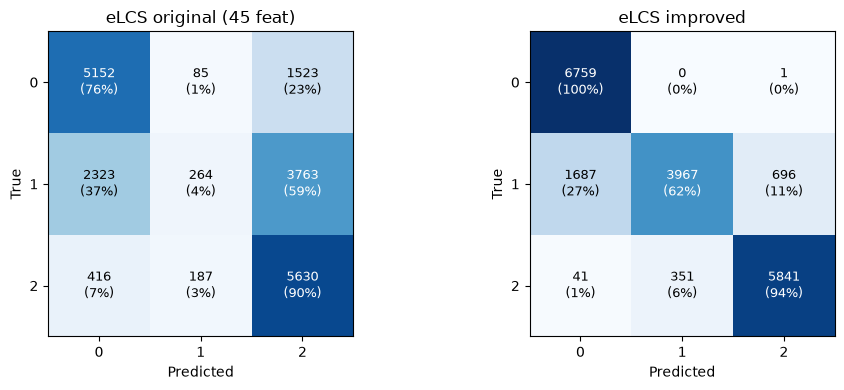

Per-class report, improved eLCS (hold-out):
              precision    recall  f1-score   support

           0      0.796     1.000     0.887      6760
           1      0.919     0.625     0.744      6350
           2      0.893     0.937     0.915      6233

    accuracy                          0.856     19343
   macro avg      0.869     0.854     0.848     19343
weighted avg      0.868     0.856     0.849     19343



In [14]:
# Confusion matrices (hold-out), counts and row-normalised
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, [BASE, REF]):
    cm = confusion_matrix(y[te], holdout[name]["pred"], labels=[0, 1, 2])
    cmn = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cmn, vmin=0, vmax=1, cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i, j]}\n({cmn[i, j]:.0%})", ha="center", va="center",
                    color="white" if cmn[i, j] > 0.5 else "black", fontsize=9)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(BAND_NAMES); ax.set_yticklabels(BAND_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(name)
plt.tight_layout(); plt.show()

print("Per-class report, improved eLCS (hold-out):")
# Converted target_names elements to string to prevent TypeError
print(classification_report(y[te], holdout[REF]["pred"], target_names=[str(x) for x in BAND_NAMES], digits=3))